<a href="https://colab.research.google.com/github/Dhiraj0079/Deep-Learning/blob/main/DLExp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def sigmoid(x):
  return (1/(1+np.exp(-x)))
def sigmoid_derivative(x):
  s=sigmoid(x)
  return s*(1-s)
layers=10
input_size=1
hidden_size=1

weights=[]
bias=[]

for i in range(layers):
  w=np.random.rand(hidden_size,hidden_size)*0.1
  b=np.random.rand(hidden_size,1)*0.1
  if i==0:
    weights.append((np.random.rand(hidden_size,input_size))*0.1)
    bias.append((np.random.rand(hidden_size,1))*0.1)

  weights.append(w)
  bias.append(b)

print(f"Network created with {layers} layers.")



Network created with 10 layers.


In [ ]:
x=np.random.rand(input_size,1)*0.1

z_values=[]
a_values=[x]

# Forward pass loop to calculate z and a for all layers
for i in range(layers):
  z=np.dot(weights[i],a_values[-1])+bias[i]
  a=sigmoid(z)
  z_values.append(z)
  a_values.append(a)

gradient=[]
output_error=np.random.rand(hidden_size,1)*0.1

dA=output_error
for i in reversed(range(layers)):
  dZ = dA * sigmoid_derivative(z_values[i])

  gradient.append(np.linalg.norm(dZ))

  if i>0:
    dA = np.dot(weights[i].T, dZ)


gradient.reverse()
print("gradient calculated")
for i in range(layers):
  print(f"Layer {i+1}: {gradient[i]}")

gradient calculated
Layer 1: 1.5762119397295633e-21
Layer 2: 5.80237472417379e-19
Layer 3: 2.095275041727753e-16
Layer 4: 8.677548749424914e-15
Layer 5: 3.808428611756518e-13
Layer 6: 2.729768802442325e-11
Layer 7: 1.1438349508622736e-09
Layer 8: 7.343318716265969e-08
Layer 9: 6.496744786203603e-05
Layer 10: 0.004167094447984237


**Graph Vanishing Gradient Effect in a Deep Neural Network VS Layer Number (from Input to Output)**

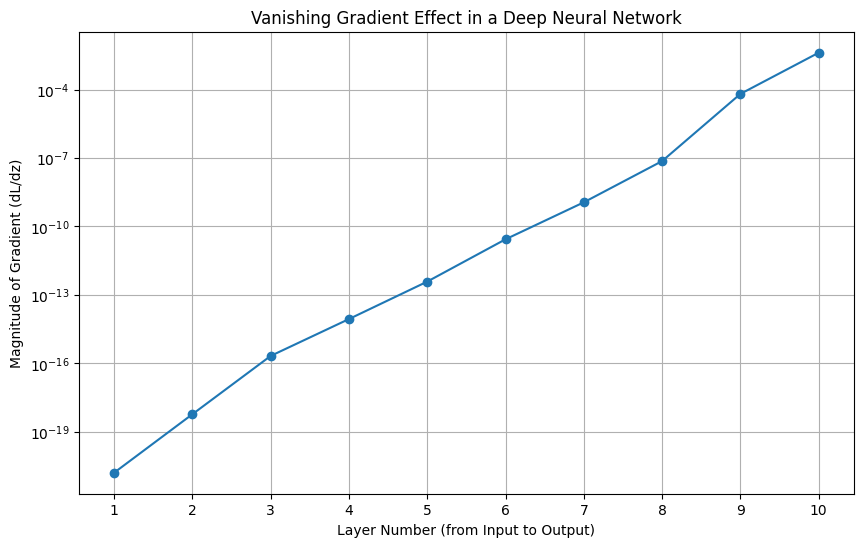

As you can see, the gradient magnitudes decrease significantly for layers closer to the input, demonstrating the vanishing gradient effect. This makes it difficult for the network to learn features in earlier layers.


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, layers + 1), gradient, marker='o')
plt.title('Vanishing Gradient Effect in a Deep Neural Network')
plt.xlabel('Layer Number (from Input to Output)')
plt.ylabel('Magnitude of Gradient (dL/dz)')
plt.yscale('log') # Use log scale to better visualize small values
plt.grid(True)
plt.xticks(range(1, layers + 1))
plt.show()

print("As you can see, the gradient magnitudes decrease significantly for layers closer to the input, demonstrating the vanishing gradient effect. This makes it difficult for the network to learn features in earlier layers.")

Initial weight: -2.8040, Initial bias: -4.1221

Epoch 1/50, Loss: 1006.2914, Gradient Magnitude: 364.2457, Weight: 177.1314, Bias: 24.0200
Epoch 6/50, Loss: 1202252910554847232.0000, Gradient Magnitude: 12638534252.8177, Weight: -6060145721.6266, Bias: -916220937.4893
Epoch 11/50, Loss: 1447476669679157953437883078541312.0000, Gradient Magnitude: 438535319944092032.0000, Weight: 210276594637769632.0000, Bias: 31791284792837976.0000
Epoch 16/50, Loss: 1742718766468630860972717769716575343160082825216.0000, Gradient Magnitude: 15216418533311509002452992.0000, Weight: -7296234821349639295336448.0000, Bias: -1103102699187824301703168.0000
Epoch 21/50, Loss: 2098181450948796837356920712297943947580434814594856284479029248.0000, Gradient Magnitude: 527983454127308325770095627337728.0000, Weight: 253166752390962474693714979586048.0000, Bias: 38275759312174635396782494842880.0000
Epoch 26/50, Loss: 2526147928059763048647289274412590864077598150612172683029103332131298529509376.0000, Gradient M

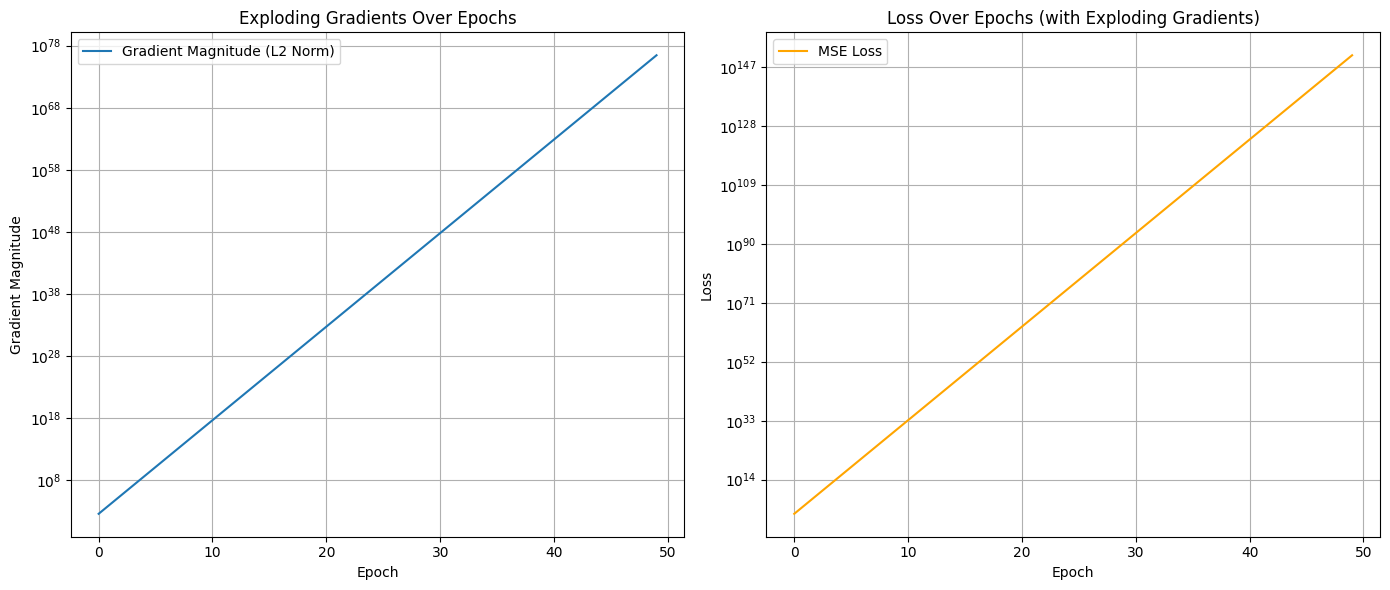

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate a simple dataset (linear regression problem)
X = np.random.rand(100, 1) * 10  # 100 samples, 1 feature
y = 2 * X + 1 + np.random.randn(100, 1) * 2 # y = 2x + 1 + noise

# 2. Define a simple neural network (single neuron, linear activation for simplicity)
# We'll manually implement forward and backward pass

# Initialize weights and bias (deliberately large to exacerbate the problem)
w = np.random.randn(1, 1) * 5 # Initial weight
b = np.random.randn(1, 1) * 5 # Initial bias

learning_rate = 0.5 # Deliberately high learning rate
n_epochs = 50 # Number of training epochs

gradient_magnitudes = [] # To store L2 norm of gradients
losses = [] # To store Mean Squared Error

print(f"Initial weight: {w[0][0]:.4f}, Initial bias: {b[0][0]:.4f}\n")

for epoch in range(n_epochs):
    # Forward pass
    y_pred = X @ w + b

    # Calculate loss (Mean Squared Error)
    loss = np.mean((y_pred - y)**2)
    losses.append(loss)

    # Backward pass (calculate gradients)
    # dL/dy_pred = 2 * (y_pred - y) / N (where N is number of samples)
    # dL/dw = dL/dy_pred * dy_pred/dw = dL/dy_pred * X
    # dL/db = dL/dy_pred * dy_pred/db = dL/dy_pred * 1

    d_loss_d_y_pred = 2 * (y_pred - y) / len(X)
    grad_w = X.T @ d_loss_d_y_pred
    grad_b = np.sum(d_loss_d_y_pred, axis=0)

    # Store gradient magnitude (L2 norm)
    gradient_magnitude = np.sqrt(np.sum(grad_w**2) + np.sum(grad_b**2))
    gradient_magnitudes.append(gradient_magnitude)

    # Update weights and bias
    w -= learning_rate * grad_w
    b -= learning_rate * grad_b

    if epoch % 5 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss:.4f}, Gradient Magnitude: {gradient_magnitude:.4f}, Weight: {w[0][0]:.4f}, Bias: {b[0][0]:.4f}")

# 3. Plot the gradient magnitudes and loss
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(range(n_epochs), gradient_magnitudes, label='Gradient Magnitude (L2 Norm)')
plt.title('Exploding Gradients Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Gradient Magnitude')
plt.yscale('log') # Use log scale to better visualize explosion
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(n_epochs), losses, label='MSE Loss', color='orange')
plt.title('Loss Over Epochs (with Exploding Gradients)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log') # Use log scale for loss as well
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

print("\n--- Demonstrating Enforcing Symmetry with ZERO Weight and Bias Sharing ---")

layers = 10
hidden_size = 1 # Each 'layer' has 1 neuron

# Define ONE shared weight and ONE shared bias, initialized to ZERO
# This will demonstrate the 'symmetry problem' even with weight sharing
shared_weight = np.zeros((hidden_size, hidden_size)) # Shape (1,1) for a single neuron, initialized to zero
shared_bias = np.zeros((hidden_size, 1)) # Shape (1,1) for a single neuron, initialized to zero

print(f"\nShared Weight (initialized to zero): {shared_weight.flatten()[0]:.4f}")
print(f"Shared Bias (initialized to zero): {shared_bias.flatten()[0]:.4f}")

# Initial input for the network
x = np.random.rand(hidden_size, 1) * 0.1
current_output = x
print(f"\nInitial Input (x): {current_output.flatten()[0]:.4f}")

# Simulate a forward pass through 10 layers, all using the SHARED ZERO parameters
for i in range(layers):
  # Each layer applies the exact same shared zero weight and bias
  z = np.dot(shared_weight, current_output) + shared_bias # This will always be zero
  current_output = z # For simplicity, using linear activation here

  print(f"Layer {i+1} Output: {current_output.flatten()[0]:.4f} (using shared ZERO W and B)")

print("\n--- Explanation ---")
print("Here, we enforce symmetry by sharing the same weight and bias across all layers. However, because these shared parameters are initialized to zero, every layer produces an output of zero regardless of the input (after the first layer). This demonstrates a different aspect of the symmetry problem: even with weight sharing, if the shared parameters themselves are symmetrically (e.g., identically to zero) initialized, the network cannot learn diverse features and becomes trivial. This highlights the importance of thoughtful initialization even when enforcing weight sharing.")



--- Demonstrating Enforcing Symmetry with ZERO Weight and Bias Sharing ---

Shared Weight (initialized to zero): 0.0000
Shared Bias (initialized to zero): 0.0000

Initial Input (x): 0.0713
Layer 1 Output: 0.0000 (using shared ZERO W and B)
Layer 2 Output: 0.0000 (using shared ZERO W and B)
Layer 3 Output: 0.0000 (using shared ZERO W and B)
Layer 4 Output: 0.0000 (using shared ZERO W and B)
Layer 5 Output: 0.0000 (using shared ZERO W and B)
Layer 6 Output: 0.0000 (using shared ZERO W and B)
Layer 7 Output: 0.0000 (using shared ZERO W and B)
Layer 8 Output: 0.0000 (using shared ZERO W and B)
Layer 9 Output: 0.0000 (using shared ZERO W and B)
Layer 10 Output: 0.0000 (using shared ZERO W and B)

--- Explanation ---
Here, we enforce symmetry by sharing the same weight and bias across all layers. However, because these shared parameters are initialized to zero, every layer produces an output of zero regardless of the input (after the first layer). This demonstrates a different aspect of the

In [ ]:
import numpy as np

print("\n--- Demonstrating Enforcing Symmetry with Weight and Bias Sharing (10 Layers, 1 Neuron Each) ---")

layers = 10
hidden_size = 1 # Each 'layer' has 1 neuron

# Define ONE shared weight and ONE shared bias
# This single set of parameters will be used by all 10 conceptual layers
shared_weight = np.random.rand(hidden_size, hidden_size) * 0.1 # Shape (1,1) for a single neuron
shared_bias = np.random.rand(hidden_size, 1) * 0.1 # Shape (1,1) for a single neuron

print(f"\nShared Weight: {shared_weight.flatten()[0]:.4f}")
print(f"Shared Bias: {shared_bias.flatten()[0]:.4f}")

# Initial input for the network
x = np.random.rand(hidden_size, 1) * 0.1
current_output = x
print(f"\nInitial Input (x): {current_output.flatten()[0]:.4f}")

# Simulate a forward pass through 10 layers, all using the SHARED parameters
for i in range(layers):
  # Each layer applies the exact same shared weight and bias
  z = np.dot(shared_weight, current_output) + shared_bias
  # For simplicity, using linear activation here; a real network would use an activation function
  current_output = z

  print(f"Layer {i+1} Output: {current_output.flatten()[0]:.4f} (using shared W and B)")

print("\n--- Explanation ---")
print("In this simulation, every 'layer' performs the identical transformation because they all utilize the exact same `shared_weight` and `shared_bias` values. This is how symmetry is explicitly enforced: all parts of the network that use these shared parameters will behave identically during the forward pass and contribute to learning the same features during training.")
print("This concept is fundamental in architectures like Convolutional Neural Networks, where a single filter (a set of shared weights) is applied across different regions of an image to detect the same features regardless of their location.")



--- Demonstrating Enforcing Symmetry with Weight and Bias Sharing (10 Layers, 1 Neuron Each) ---

Shared Weight: 0.0891
Shared Bias: 0.0135

Initial Input (x): 0.0342
Layer 1 Output: 0.0165 (using shared W and B)
Layer 2 Output: 0.0150 (using shared W and B)
Layer 3 Output: 0.0148 (using shared W and B)
Layer 4 Output: 0.0148 (using shared W and B)
Layer 5 Output: 0.0148 (using shared W and B)
Layer 6 Output: 0.0148 (using shared W and B)
Layer 7 Output: 0.0148 (using shared W and B)
Layer 8 Output: 0.0148 (using shared W and B)
Layer 9 Output: 0.0148 (using shared W and B)
Layer 10 Output: 0.0148 (using shared W and B)

--- Explanation ---
In this simulation, every 'layer' performs the identical transformation because they all utilize the exact same `shared_weight` and `shared_bias` values. This is how symmetry is explicitly enforced: all parts of the network that use these shared parameters will behave identically during the forward pass and contribute to learning the same features 